# Create a pretty period eccentricity plot

- colored by mass
- interactive with plotly



In [1]:
import json
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
import os, sys
from pathlib import Path
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import MAIN_CATALOG, DOCS_DIR, PLOTS_DIR
file_path = MAIN_CATALOG

# # Import latex fonts for plotting
# plt.rcParams.update({"text.usetex": True,
#                      "font.family": "serif",
#                      "font.serif": ["Times"],
#                      "font.size": 14,
#                      "axes.labelsize": 25,
#                      "legend.fontsize": 25,
#                      "xtick.labelsize": 20,
#                      "ytick.labelsize": 20})

In [2]:
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None


def extract_central_value(entry, key):
    # Expects [err-, value, err+], returns value or np.nan
    val = entry.get(key, [np.nan, np.nan, np.nan])
    if isinstance(val, list) and len(val) == 3:
        return val[1]
    elif isinstance(val, (int, float)):
        return val
    else:
        return np.nan


def extract_error_minus(entry, key):
    # Returns the lower error (err-) from [err-, value, err+] or np.nan
    val = entry.get(key, None)
    if isinstance(val, list) and len(val) == 3:
        try:
            return float(val[0])
        except Exception:
            return np.nan
    return np.nan


def extract_error_plus(entry, key):
    # Returns the upper error (err+) from [err-, value, err+] or np.nan
    val = entry.get(key, None)
    if isinstance(val, list) and len(val) == 3:
        try:
            return float(val[2])
        except Exception:
            return np.nan
    return np.nan


def extract_column(data, key):
    return [extract_central_value(entry, key) for entry in data]


def extract_error_columns(data, key):
    """Return two lists: error_minus, error_plus for the given key across data."""
    errs_lo = [extract_error_minus(entry, key) for entry in data]
    errs_hi = [extract_error_plus(entry, key) for entry in data]
    return errs_lo, errs_hi


# Read data
data = read_json_file(str(file_path))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)

# Build a single DataFrame with central values and errors
df = pd.DataFrame({
    'Period': extract_column(data, 'Period'),
    'Period_err_minus': extract_error_columns(data, 'Period')[0],
    'Period_err_plus': extract_error_columns(data, 'Period')[1],
    'Eccentricity': extract_column(data, 'Eccentricity'),
    'Ecc_err_minus': extract_error_columns(data, 'Eccentricity')[0],
    'Ecc_err_plus': extract_error_columns(data, 'Eccentricity')[1],
    'M1': extract_column(data, 'M1'),
    'M1_err_minus': extract_error_columns(data, 'M1')[0],
    'M1_err_plus': extract_error_columns(data, 'M1')[1],
    'M2': extract_column(data, 'M2'),
    'M2_err_minus': extract_error_columns(data, 'M2')[0],
    'M2_err_plus': extract_error_columns(data, 'M2')[1],
    'System Name': [entry.get('System Name', '') for entry in data],
    'Type1': [entry.get('Type1', '') for entry in data],
    'Type2': [entry.get('Type2', '') for entry in data],
    'class': [entry.get('class', 'Unclassified') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})




In [3]:
# Hand-picked colors for each class (hex strings). Adjust as you like.
COLORMAP = {
    'Algols': '#6d2c14',            # maroon
    'contact binaries': '#f49856',  # light olive
    'Hot subdwarfs': '#6d4aa0', # UV purple #6d4aa0
    'Stripped stars': '#408c63', # muted green
    'Post AGB stars': '#ea4d4d', # coral/red 
    'Wolf-Rayet': '#52b4e5',     # blue 
    'Blue Straggler Stars': '#4a7ed6', # '#af52a6',    # purple  
    'Barium stars': '#f4d25a',
    'White Dwarf': '#e6cfd9',    # purple 
    'Neutron star': '#9bd24e',   # lime green
    'Black Holes': '#565656',   # orange
    'Unclassified': '#cbd24f'
}

SYMBOLS = [
    'o', 'd', 's',  '^', 'D', 'v', '8', 'p', 'h', 
]
SYMBOLMAP = {k: SYMBOLS[i % len(SYMBOLS)] for i, k in enumerate(COLORMAP.keys())}


# z-order mapping: lower numbers are drawn first (underneath)
zorder_map = { 'White Dwarf': 0 }  # put White Dwarf at bottom
default_z = 2                        # default z-order for other classes
err_z_offset = 0.5                   # errorbars slightly above the marker z-order



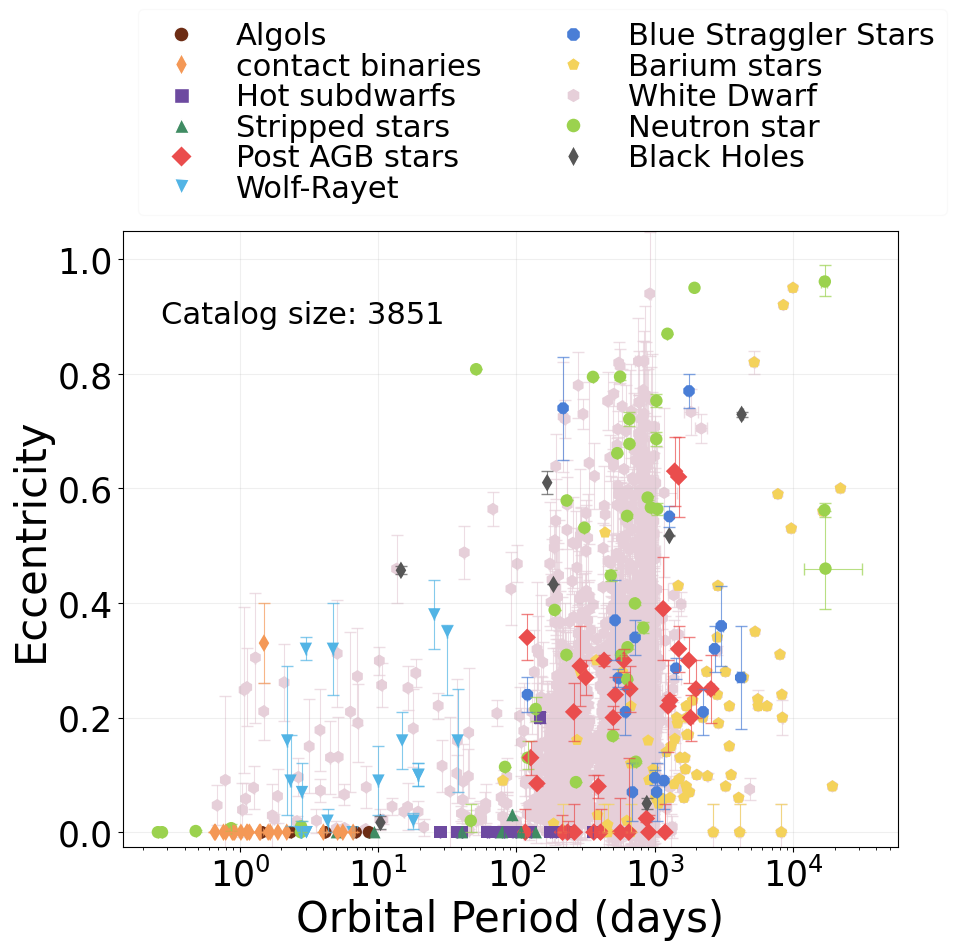

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))


# Plot per-class so we can control color and zorder
for cls, group in df.groupby('class'):
    color = COLORMAP.get(cls, '#666666')
    marker = SYMBOLMAP.get(cls, 'o')
    z = zorder_map.get(cls, default_z)

    ax.scatter(group['Period'], group['Eccentricity'], marker=marker,
               color=color, s=80, edgecolors='none', zorder=z, label=cls)

    # plot errorbars for this group using a slightly higher z so they appear above markers
    ax.errorbar(group['Period'], group['Eccentricity'],
                xerr=[group['Period_err_minus'], group['Period_err_plus']],
                yerr=[group['Ecc_err_minus'], group['Ecc_err_plus']],
                fmt='none', capsize=4, ecolor=color, alpha=0.7,
                elinewidth=0.8, zorder=z + err_z_offset)

# Legend
from matplotlib.lines import Line2D
present_classes = [c for c in COLORMAP.keys() if c in df['class'].unique()]
present_marker = {c: SYMBOLMAP.get(c, 'o') for c in present_classes}
legend_handles = [
    Line2D([0], [0], marker=present_marker[c], color='w', label=c, markerfacecolor=COLORMAP[c], markersize=6)
    for c in present_classes
]
if legend_handles:
    ax.legend(handles=legend_handles, loc='lower left', 
    bbox_to_anchor=(0., 1.), framealpha=0.1, fontsize=22,
    ncols=2, markerscale=1.8, labelspacing=0.05, 
    )

# if legend_handles:
#     ax.legend(handles=legend_handles, loc='upper left', 
#     bbox_to_anchor=(0.98, 1), framealpha=0.1, fontsize=22,
#     ncols=1, markerscale=1.8, labelspacing=0.05, 
#     )

ax.text(0.05, 0.85, f'Catalog size: {len(df)}', 
transform=ax.transAxes, ha='left', fontsize = 22)

# plot values
#Set tick size
ax.tick_params(axis='both', which='major', labelsize=25)
ax.set_xscale('log')
ax.set_xlabel('Orbital Period (days)', size =30)
ax.set_ylabel('Eccentricity', size=30)
ax.set_ylim(-0.025, 1.05)
ax.grid(True, alpha=0.2)
plt.savefig(PLOTS_DIR / 'period_eccentricity_class.pdf', bbox_inches='tight')
plt.show()


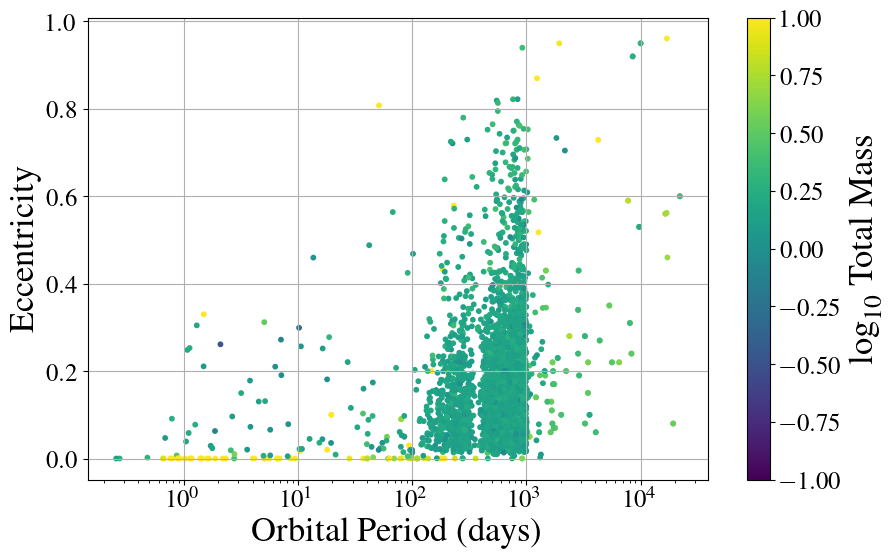

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

plt.scatter(df['Period'], df['Eccentricity'], 
            c=np.log10(df['M1']+df['M2']), s=10, vmin = -1, vmax = 1 )
# plt.errorbar(df['Period'], df['Eccentricity'], 
#               xerr=[df['Period_err_minus'], df['Period_err_plus']], 
#               yerr=[df['Ecc_err_minus'], df['Ecc_err_plus']], fmt='none', capsize=5)
plt.colorbar(label='$\log_{10}$ Total Mass') 

# plot values
ax.set_xscale('log')
ax.set_xlabel('Orbital Period (days)')
ax.set_ylabel('Eccentricity')
# ax.set_title('Period-Eccentricity Distribution')
ax.grid(True)
plt.savefig(PLOTS_DIR / 'period_eccentricity_masscolor.pdf', bbox_inches='tight')
plt.show()



In [ ]:
#  # Add a slider for total mass
# df['Total Mass'] = df['M1'] + df['M2']
# df['logMtot'] = np.log10(df['M1'] + df['M2'])

# # Now make an interactive plotly version with mass as a slider
# fig = px.scatter(df, x='Period', y='Eccentricity',
#                  animation_frame='logMtot',
#                  animation_group='System Name',
#                 #  size="Total Mass", 
#                  color='class',
#                  color_discrete_map=COLORMAP,
#                  symbol='class',
#                  symbol_map=SYMBOLMAP,
#                  hover_data={
#                      'System Name': True,
#                      'M1': ':.2f','M2': ':.2f',
#                      'Type1': True,'Type2': True,},
#                  size_max=15,
#                  log_x=True,
#                  range_x=[1,1e3], range_y=[0,1]
#                 # template='plotly_white'
#                 )

# # fig = px.scatter(df, x="gdpPercap", y="lifeExp", 
# #                 animation_frame="year", 
# #                 animation_group="country",
# #            size="pop", color="continent", hover_name="country",
# #            log_x=True, size_max=55, range_x=[100,100000], range_y=[25,90])

# # Add error bars
# fig.update_traces(error_x=dict(type='data', array=df['Period_err_plus'], arrayminus=df['Period_err_minus'], visible=True),
#                   error_y=dict(type='data', array=df['Ecc_err_plus'], arrayminus=df['Ecc_err_minus'], visible=True))               

# fig["layout"].pop("updatemenus") # optional, drop animation buttons

# fig.show()
                

In [75]:
# compute total mass safely (fill NaNs)
df['Total Mass'] = df['M1'].fillna(0.0) + df['M2'].fillna(0.0)
# log10(total mass) only for positive totals, else NaN
df['logMtot'] = np.where(df['Total Mass'] > 0, np.log10(df['Total Mass']), np.nan)


# drop rows that don't have the required plotting values
#    (Period and Eccentricity must be numeric; drop rows with NaNs there)
plot_df = df.dropna(subset=['Period', 'Eccentricity']).copy()


######################################
## Create mass bins
# fixed log-space bins from -2.0 to 1.5 in 0.5 steps
bins = np.arange(-2.0, 1.5 + 0.5, 0.5)  # [-2.0, -1.5, ..., 1.5]
labels = [f"{bins[i]:.1f}–{bins[i+1]:.1f}" for i in range(len(bins)-1)]
plot_df['mass_bin'] = pd.cut(plot_df['logMtot'], bins=bins, labels=labels,
                            include_lowest=True, right=False).astype(object)

# mark values outside the range explicitly
plot_df.loc[plot_df['logMtot'] < bins[0], 'mass_bin'] = f"<{bins[0]:.1f}"
plot_df.loc[plot_df['logMtot'] >= bins[-1], 'mass_bin'] = f">={bins[-1]:.1f}"


# build the animated scatter using the discrete 'mass_bin'
fig = px.scatter(
    plot_df,
    x='Period',
    y='Eccentricity',
    color='class',
    color_discrete_map=COLORMAP,
    symbol='class',
    symbol_map=SYMBOLMAP,
    hover_data={'System Name': True, 'M1': ':.2f', 'M2': ':.2f', 'Type1': True, 'Type2': True},
    # size='_size',
    animation_frame='mass_bin',
    animation_group='System Name',
    size_max=15,
    log_x=True,
    range_x=[1, 1e3],
    range_y=[0, 1],
    template='plotly_white'
)


fig.show()

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

divide by zero encountered in log10



In [68]:
# Now make an interactive plotly version with mass as a slider
# Compute total mass and create mass bins for the slider
df['Total Mass'] = (df['M1'].fillna(0) + df['M2'].fillna(0)).astype(float)
# Create quantile-based bins to get a reasonable number of slider frames (e.g. 10)
n_bins = 10
# Handle constant or NaN total mass gracefully
if df['Total Mass'].isnull().all() or df['Total Mass'].nunique() <= 1:
    df['mass_bin'] = 'all'
else:
    # we label bins as strings so the slider displays readable tick labels
    df['mass_bin'] = pd.qcut(df['Total Mass'], q=n_bins, duplicates='drop').astype(str)

# Build the animated scatter with animation_frame set to the mass bin
# Ensure size column is numeric and has no NaNs (Plotly requires numeric sizes)
size_col = df['M1'].copy()
# Replace NaN with a small positive floor so markers remain visible
size_col = size_col.fillna(df['M1'].median() if df['M1'].notnull().any() else 1.0)
# Enforce a minimum marker size (e.g., 3) and scale for better visibility
size_col = (size_col - size_col.min()) / (size_col.max() - size_col.min() + 1e-9) * 12 + 3

fig = px.scatter(df.assign(_size=size_col), x='Period', y='Eccentricity',
                 color='class',
                 color_discrete_map=COLORMAP,
                 symbol='class',
                 symbol_map=SYMBOLMAP,
                 hover_data={'System Name': True, 'M1': ':.2f', 'M2': ':.2f', 'Type1': True, 'Type2': True},
                 size='_size',                 # use safe computed size column
                 animation_frame='mass_bin',
                 animation_group='System Name',
                 size_max=15,
                 log_x=True,
                 template='plotly_white')

# Optionally attach error bars if present
try:
    fig.update_traces(error_x=dict(type='data', array=df['Period_err_plus'], arrayminus=df['Period_err_minus']),
                      error_y=dict(type='data', array=df['Ecc_err_plus'], arrayminus=df['Ecc_err_minus']))
except Exception:
    pass

# Improve layout: set slider title and format ticks
fig.update_layout(title='Period vs Eccentricity — slider = Total Mass bins',
                  legend_title_text='Class')
fig.show()